In [3]:
#5,7,11
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
print(torch.__version__)
print(torch.cuda.is_available())

2.9.1+rocm6.4
True


### Zadanie 5

In [4]:
device = torch.device('cuda')
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

dim = np.prod(X_train.shape[1:])
X_train = X_train.astype('float32') / X_train.max()
X_test = X_test.astype('float32') / X_train.max()
X_train = X_train.reshape(-1, dim)
X_test = X_test.reshape(-1, dim)
num_classes = len(np.unique(y_train))

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.network(x)

model = FashionNet().to(device)

/tmp/ipykernel_15869/4251199909.py:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))


In [5]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if
p.requires_grad)
print(f"Parametry: {total_params:,} (trenowalnych: {trainable_params:,})")

Parametry: 243,530 (trenowalnych: 243,530)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.5, patience=3)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        outputs = model(batch_x)
        loss = criterion(outputs,batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_x.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(batch_y).sum().item()
        total += batch_y.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item() * batch_x.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(batch_y).sum().item()
            total += batch_y.size(0)

        return total_loss / total, correct / total

epochs = 50
best_val_loss = float('inf')
patience = 7
patience_counter = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping: {epoch+1}")
        break

    if (epoch + 1) % 5 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoka {epoch+1}:\nTrain loss: {train_loss:.4f},\nValidation loss: {val_loss:.4f}')

model.load_state_dict(best_state)
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Epoka 5:
Train loss: 0.4836,
Validation loss: 0.3329
Epoka 10:
Train loss: 0.4381,
Validation loss: 0.3058
Epoka 15:
Train loss: 0.4104,
Validation loss: 0.2947
Epoka 20:
Train loss: 0.3937,
Validation loss: 0.2797
Epoka 25:
Train loss: 0.3756,
Validation loss: 0.2873
Epoka 30:
Train loss: 0.3738,
Validation loss: 0.2759
Epoka 35:
Train loss: 0.3612,
Validation loss: 0.2680
Epoka 40:
Train loss: 0.3559,
Validation loss: 0.2670
Epoka 45:
Train loss: 0.3459,
Validation loss: 0.2626
Epoka 50:
Train loss: 0.3445,
Validation loss: 0.2612
Test accuracy: 0.8437
Test loss: 36.1107


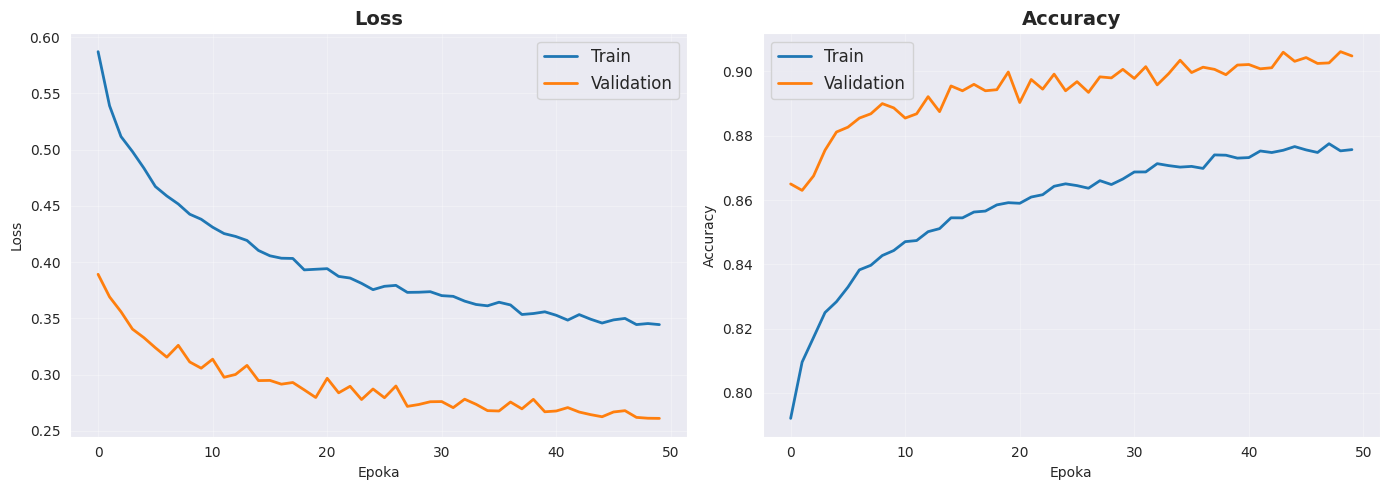

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train', linewidth=2)
axes[0].plot(val_losses, label='Validation', linewidth=2)
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train', linewidth=2)
axes[1].plot(val_accs, label='Validation', linewidth=2)
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()